In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print(os.getcwd())
os.chdir("../../soge-home/projects/mistral/mans4178/schools")
print(os.getcwd())

/hn01-home/mans4178
/lustre/soge1/projects/mistral/mans4178/schools


In [3]:
ISO3 = "NGA"

### Prepare survey data

Household survey source:
https://microdata.worldbank.org/index.php/catalog/3827/

In [4]:
survey_c = pd.read_csv("validation/survey_data/NGA/NGA_2018_LSS_v01_M_CSV/sect2_education.csv")

/tmp/ipykernel_173527/2624811240.py:1: DtypeWarning: Columns (30,36,40,45,48) have mixed types. Specify dtype option on import or set low_memory=False.
  survey_c = pd.read_csv("validation/survey_data/NGA/NGA_2018_LSS_v01_M_CSV/sect2_education.csv")


In [5]:
print("Number of survey responses: "+str(len(survey_c)))
print("Number of non-empty responses: "+str(survey_c.s02q14b.count()))

Number of survey responses: 116320
Number of non-empty responses: 38387


In [6]:
# Filter empty responses
survey_c = survey_c[survey_c["s02q14b"].notnull()]

In [7]:
# Add household weights
survey_a = pd.read_csv("validation/survey_data/NGA/NGA_2018_LSS_v01_M_CSV/secta_cover.csv")
survey = survey_c.merge(survey_a[["hhid","wt_final"]],
                          how = "left")

In [8]:
def survey_match(x):
    if x == 1:
        return 1
    elif x == 2:
        return (0+15)/2
    elif x == 3:
        return (16+30)/2
    elif x ==4: 
        return (31+60)/2
    elif x == 5:
        return (61+90)/2
    elif x == 6:
        return (91+120)/2
    elif x == 7:
        return (121+180)/2

In [9]:
# Convert format
survey["traveltime"] = survey.apply(lambda x: survey_match(x["s02q14b"]), axis=1)

In [10]:
# Filter not tertiary
survey = survey[(survey['s02q10'] >= 10) & (survey['s02q10'] <=30)]

In [11]:
print("Number of non-empty, primary and secondary schools only responses: "+str(survey.traveltime.count()))

Number of non-empty, primary and secondary schools only responses: 28432


In [12]:
# Filter only walking 
survey = survey[survey["s02q14a"]==2]

# Filter only not-walking 
# survey = survey[survey["s02q14a"]!=2]

In [13]:
print("Number of non-empty, primary and secondary schools, walking only responses: "+str(survey.traveltime.count()))

Number of non-empty, primary and secondary schools, walking only responses: 24591


In [14]:
tt_col = "traveltime"
weight_col = "wt_final"

### Import model data

In [15]:
df_summary_1km = pd.read_csv(
    f"model_1km/outputs/jrc/{ISO3}/analysis/ttpop_nat__{ISO3}.csv", 
    index_col=0)

df_summary_90m = pd.read_csv(
    f"model_90m/outputs/jrcwalking/{ISO3}/analysis/ttpop_nat__{ISO3}.csv", 
    index_col=0)

### Plot distributions (nationally)

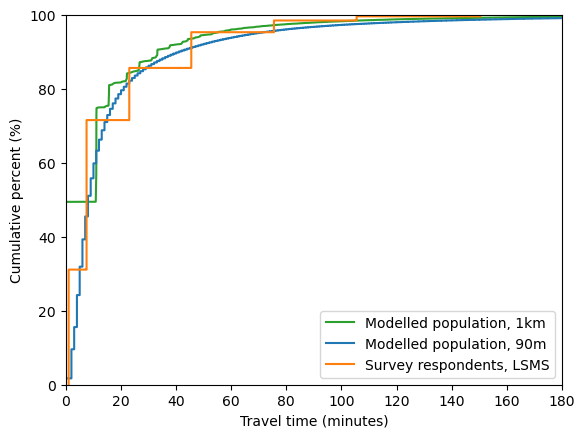

In [16]:
fig, ax = plt.subplots()
sns.ecdfplot(data=df_summary_1km, x="traveltime", weights="pop", stat="percent", label="Modelled population, 1km", color=sns.color_palette()[2])
sns.ecdfplot(data=df_summary_90m, x="traveltime", weights="pop", stat="percent", label="Modelled population, 90m", color=sns.color_palette()[0])
sns.ecdfplot(data=survey, x=tt_col, weights=weight_col, stat="percent", label="Survey respondents, LSMS", color=sns.color_palette()[1])
ax.set_xlim([0, 180])
ax.set_ylim([0, 100])
ax.set_xlabel("Travel time (minutes)")
ax.set_ylabel("Cumulative percent (%)")
ax.legend(loc ='lower right')
plt.show()

### Compare CDFs (areas between curves)

In [17]:
import validation.ipynb.compare_cdfs as compare_cdfs

In [18]:
metrics_90m = compare_cdfs.compare_cdfs(df_summary_90m,
                                        survey,
                                        tmax=120,
                                        time_col=tt_col, 
                                        weight_col=weight_col)

In [19]:
metrics_1km = compare_cdfs.compare_cdfs(df_summary_1km,
                                        survey,
                                        tmax=120,
                                        time_col=tt_col, 
                                        weight_col=weight_col)

In [21]:
table = pd.DataFrame([metrics_90m, metrics_1km], index=["90m model", "1km model"])
table = table.reset_index().rename(columns={"index": "model"})
table.insert(0, "ISO3", ISO3)
table.to_csv(f"validation/model_comp/cdf_metrics__{ISO3}.csv")
table

,ISO3,model,A+,A-,Aabs,A+_norm,A-_norm,Aabs_norm
0,NGA,90m model,0.008565,5.550139,5.558704,0.000071,0.046251,0.046323
1,NGA,1km model,0.647209,2.459986,3.107195,0.005393,0.020500,0.025893
